In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
df_cancer = load_breast_cancer(as_frame=True).frame
df_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [21]:
df_cancer.shape
print("filas {} y columnas {}".format(df_cancer.shape[0], df_cancer.shape[1]))

filas 569 y columnas 31


In [22]:
df_wines_red = pd.read_csv("winequality-red.csv", sep=";")
df_wines_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [23]:
df_wines_white = pd.read_csv("winequality-white.csv", sep=";")
df_wines_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [24]:
print("filas {} y columnas {}".format(df_wines_white.shape[0], df_wines_white.shape[1]))
print("filas {} y columnas {}".format(df_wines_red.shape[0], df_wines_red.shape[1]))

filas 4898 y columnas 12
filas 1599 y columnas 12


In [25]:
df_wines = pd.merge(df_wines_red, df_wines_white, how="outer")
df_wines.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,3.8,0.310,0.02,11.1,0.036,20.0,114.0,0.99248,3.75,0.44,12.4,6
1,3.9,0.225,0.40,4.2,0.030,29.0,118.0,0.98900,3.57,0.36,12.8,8
2,4.2,0.170,0.36,1.8,0.029,93.0,161.0,0.98999,3.65,0.89,12.0,7
3,4.2,0.215,0.23,5.1,0.041,64.0,157.0,0.99688,3.42,0.44,8.0,3
4,4.4,0.320,0.39,4.3,0.030,31.0,127.0,0.98904,3.46,0.36,12.8,8


In [26]:
print("filas {} y columnas {}".format(df_wines.shape[0], df_wines.shape[1]))

filas 6495 y columnas 12


In [27]:
df_wines.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6495.000000,6495.000000,6495.000000,6495.00000,6495.000000,6495.000000,6495.000000,6495.000000,6495.000000,6495.000000,6495.000000,6495.000000
mean,7.215589,0.339698,0.318656,5.44428,0.056042,30.520400,115.744034,0.994697,3.218479,0.531304,10.491768,5.818322
std,1.296515,0.164650,0.145333,4.75816,0.035034,17.748962,56.529715,0.002999,0.160806,0.148814,1.192738,0.873208
min,3.800000,0.080000,0.000000,0.60000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.80000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.00000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.10000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.80000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [28]:
df_wines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6495 entries, 0 to 6494
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6495 non-null   float64
 1   volatile acidity      6495 non-null   float64
 2   citric acid           6495 non-null   float64
 3   residual sugar        6495 non-null   float64
 4   chlorides             6495 non-null   float64
 5   free sulfur dioxide   6495 non-null   float64
 6   total sulfur dioxide  6495 non-null   float64
 7   density               6495 non-null   float64
 8   pH                    6495 non-null   float64
 9   sulphates             6495 non-null   float64
 10  alcohol               6495 non-null   float64
 11  quality               6495 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.0 KB


In [29]:
df_wines["quality"].value_counts()

quality
6    2836
5    2137
7    1078
4     216
8     193
3      30
9       5
Name: count, dtype: int64

In [30]:
df_wines.corr(numeric_only=True)['quality'].abs().sort_values(ascending=False)[1:]

alcohol                 0.444139
density                 0.305749
volatile acidity        0.265830
chlorides               0.200517
citric acid             0.085501
fixed acidity           0.076830
free sulfur dioxide     0.055636
total sulfur dioxide    0.041288
sulphates               0.038607
residual sugar          0.036971
pH                      0.019548
Name: quality, dtype: float64

In [31]:
# Preparación de los datos
X = df_wines.drop("quality", axis=1)
y = df_wines["quality"].to_frame()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Accuracy: 0.6882217090069284
Random Forest Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.57      0.11      0.18        37
           5       0.72      0.72      0.72       419
           6       0.66      0.78      0.71       580
           7       0.73      0.54      0.63       224
           8       0.93      0.37      0.53        35

    accuracy                           0.69      1299
   macro avg       0.60      0.42      0.46      1299
weighted avg       0.69      0.69      0.68      1299

Random Forest Confusion Matrix:
 [[  0   0   2   2   0   0]
 [  0   4  18  14   1   0]
 [  0   2 303 111   3   0]
 [  0   1  95 452  32   0]
 [  0   0   3  98 122   1]
 [  0   0   1  13   8  13]]


/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
svm_model = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVM Accuracy: 0.588144726712856
SVM Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.38      0.08      0.13        37
           5       0.62      0.67      0.65       419
           6       0.57      0.70      0.63       580
           7       0.57      0.33      0.42       224
           8       0.33      0.03      0.05        35

    accuracy                           0.59      1299
   macro avg       0.41      0.30      0.31      1299
weighted avg       0.58      0.59      0.57      1299

SVM Confusion Matrix:
 [[  0   0   3   1   0   0]
 [  1   3  23  10   0   0]
 [  1   4 282 128   4   0]
 [  0   1 139 405  35   0]
 [  0   0   7 142  73   2]
 [  0   0   0  19  15   1]]


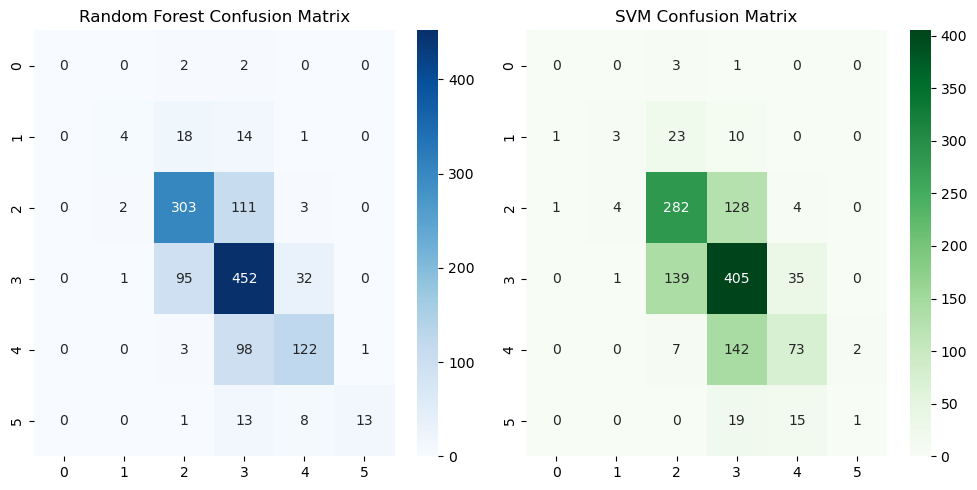

In [35]:
#Representacion grafica de la matriz de confusion
import seaborn as sns
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens')
plt.title('SVM Confusion Matrix')
plt.tight_layout()
plt.show()